# Sales LSTM — model tuning

Questo notebook seleziona il modello LSTM per la previsione di `daily_total_sales`.

La procedura:
- costruisce gli split temporali per store;
- confronta una griglia di finestre, architetture, dropout e learning rate;
- seleziona le configurazioni sulla sola `val_loss`;
- conserva su disco solo i modelli top-k;
- promuove una configurazione selezionata nella cartella del modello sales (la prima di default);
- calcola le metriche predittive finali su train, validation e test.

Il test set non contribuisce alla selezione degli iperparametri.

## Import e dipendenze

Le funzioni generiche per sequenze e input Keras sono in `lstm_utils.py`; il preprocessing e l'architettura specifici del caso sales sono in `sales_level_shift_utils.py`.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pickle
import shutil
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from tqdm.auto import tqdm
from IPython.display import display

from lstm_utils import build_model_inputs

from sales_level_shift_utils import (
    get_feature_lists,
    build_dataset_train_val,
    build_dataset_train_val_test_from_artifacts,
    build_lstm_sales_model,
)

from project_paths import (
    CLEAN_DATA_PATH,
    SALES_MODEL_DIR,
    LEVEL_SHIFT_RESULTS_DIR,
    ensure_artifact_directories,
)

## Configurazione e artifact

La cella definisce percorsi, parametri di training, griglia di tuning, flag di ricalcolo e nomi degli artifact.

Con `FORCE_RECOMPUTE_TUNING = False`, la presenza di artifact del tuning evita il riavvio della griglia. Le metriche finali possono essere ricalcolate separatamente tramite `FORCE_RECOMPUTE_FINAL_METRICS`.

In [3]:
# Crea le directory degli artifact se mancanti
ensure_artifact_directories()

# Dataset e directory di output
DATA_PATH = CLEAN_DATA_PATH

OUTPUT_DIR = SALES_MODEL_DIR / "tuning"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TUNING_RESULTS_DIR = LEVEL_SHIFT_RESULTS_DIR / "lstm_tuning"
TUNING_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = TUNING_RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TOP_MODELS_DIR = OUTPUT_DIR / "top_models"
TOP_MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Numero massimo di configurazioni top-k conservate su disco
TOP_K_MODELS_TO_SAVE = 10

# Addestramento e split temporale per store
BATCH_SIZE = 64
EPOCHS = 200
PATIENCE = 25

TRAIN_SIZE = 0.70
VAL_SIZE = 0.10

RANDOM_SEED = 42

# Griglia architetturale
ARCHITECTURE_CONFIGS = [
    {
        "architecture_name": "small",
        "lstm_units": 32,
        "seq_dense_units": 16,
        "dense_1_units": 32,
        "dense_2_units": 16,
    },
    {
        "architecture_name": "medium",
        "lstm_units": 64,
        "seq_dense_units": 32,
        "dense_1_units": 64,
        "dense_2_units": 32,
    },
    {
        "architecture_name": "large",
        "lstm_units": 128,
        "seq_dense_units": 64,
        "dense_1_units": 128,
        "dense_2_units": 64,
    },
]

WINDOW_SIZE_VALUES = [7, 14, 21, 28]

LEARNING_RATE_VALUES = [
    5e-4,
    1e-3,
]

# Iperparametri condivisi dalla griglia
DROPOUT_VALUES = [
    0.0,
    0.025,
    0.05,
    0.10,
]

# Cache e ricalcolo
FORCE_REBUILD_DATASETS = False

# Forza l'esecuzione completa della griglia anche in presenza di artifact precedenti
FORCE_RECOMPUTE_TUNING = False

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

grid_size = (
    len(ARCHITECTURE_CONFIGS)
    * len(WINDOW_SIZE_VALUES)
    * len(LEARNING_RATE_VALUES)
    * len(DROPOUT_VALUES)
)

# Artifact prodotti dal tuning e dalla promozione del modello
TUNING_RESULTS_PATH = TUNING_RESULTS_DIR / "sales_lstm_tuning_results.csv"
TOP_MODELS_PATH = TUNING_RESULTS_DIR / "top_sales_lstm_models.csv"
TOP_MODELS_PICKLE_PATH = TUNING_RESULTS_DIR / "top_sales_lstm_models.pkl"
BEST_CONFIG_PATH = OUTPUT_DIR / "best_sales_lstm_config.pkl"
BEST_MODEL_PATH = OUTPUT_DIR / "best_lstm_sales.keras"
BEST_HISTORY_PATH = OUTPUT_DIR / "best_history.pkl"
FINAL_SPLIT_METRICS_PATH = TUNING_RESULTS_DIR / "final_model_split_metrics.csv"

# Forza il ricalcolo delle metriche predittive sul modello promosso
FORCE_RECOMPUTE_FINAL_METRICS = False


def find_existing_tuning_evidence():
    """Individua qualsiasi artifact sufficiente a indicare un tuning già eseguito."""
    evidence_paths = [
        TUNING_RESULTS_PATH,
        TOP_MODELS_PATH,
        TOP_MODELS_PICKLE_PATH,
        BEST_CONFIG_PATH,
        BEST_MODEL_PATH,
        BEST_HISTORY_PATH,
        OUTPUT_DIR / "feature_scalers.pkl",
        OUTPUT_DIR / "mappings.pkl",
        OUTPUT_DIR / "features.pkl",
        SALES_MODEL_DIR / "lstm_sales.keras",
        SALES_MODEL_DIR / "training_config.pkl",
        SALES_MODEL_DIR / "history.pkl",
        SALES_MODEL_DIR / "feature_scalers.pkl",
        SALES_MODEL_DIR / "mappings.pkl",
        SALES_MODEL_DIR / "features.pkl",
    ]

    evidence = [path for path in evidence_paths if path.exists()]

    for directory in [
        TOP_MODELS_DIR,
        SALES_MODEL_DIR / "top_models",
        SALES_MODEL_DIR / "top_10_models",
    ]:
        if directory.exists() and any(directory.glob("*.keras")):
            evidence.append(directory)

    return evidence


EXISTING_TUNING_EVIDENCE = find_existing_tuning_evidence()

# La presenza di artifact precedenti evita il riavvio della griglia
TUNING_ALREADY_COMPLETED = (
    not FORCE_RECOMPUTE_TUNING
    and len(EXISTING_TUNING_EVIDENCE) > 0
)

if TUNING_ALREADY_COMPLETED:
    print("Tuning già rilevato: train/validation e griglia non verranno ricalcolati.")
    print("Artifact trovato:", EXISTING_TUNING_EVIDENCE[0])

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Numero configurazioni:", grid_size)

Tuning già rilevato: train/validation e griglia non verranno ricalcolati.
Artifact trovato: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_tuning\sales_lstm_tuning_results.csv
DATA_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\clean\all_stores_cashflow.csv
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\models\sales\tuning
Numero configurazioni: 96


## Dataset clean

Il dataset viene ordinato per store e data prima della costruzione degli split temporali.

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset non trovato: {DATA_PATH}. Esegui prima data_generation.py."
    )

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["store_id", "date"]).reset_index(drop=True)

display(df.head())
print(df.shape)

,date,store_id,year,month,day,week_day,holiday,actual_holiday,pre_holiday,weekend,...,pos_delay_type,pos_delay_event_id,pos_volume_ratio,is_level_shift_anomaly,lsa_type,lsa_severity,lsa_mult,lsa_event_id,lsa_day_in_event,lsa_duration
0,2018-01-01,0,2018,1,1,0,1,1,0,0,...,normal,-1,0.738507,0,normal,normal,1.0,-1,-1,0
1,2018-01-02,0,2018,1,2,1,0,0,0,0,...,normal,-1,0.818931,0,normal,normal,1.0,-1,-1,0
2,2018-01-03,0,2018,1,3,2,0,0,0,0,...,normal,-1,0.964367,0,normal,normal,1.0,-1,-1,0
3,2018-01-04,0,2018,1,4,3,0,0,0,0,...,normal,-1,0.989017,0,normal,normal,1.0,-1,-1,0
4,2018-01-05,0,2018,1,5,4,0,0,1,0,...,normal,-1,1.448145,0,normal,normal,1.0,-1,-1,0


(25570, 59)


## Schema delle feature

La definizione delle feature è centralizzata in `sales_level_shift_utils.py`, così il tuning e le successive pipeline sales usano lo stesso schema.

In [5]:
features_preview = get_feature_lists()
features_preview

{'seq_num': ['daily_total_sales'],
 'seq_bool': ['holiday', 'actual_holiday', 'pre_holiday'],
 'seq_cat': ['week_day', 'month', 'day'],
 'final_num': ['time_idx', 'oil_price', 'consumer_confidence', 'fao'],
 'final_bool': ['holiday', 'actual_holiday', 'pre_holiday'],
 'cat': ['store_id', 'week_day', 'month', 'day'],
 'ground_truth': ['is_level_shift_anomaly',
  'lsa_type',
  'lsa_mult',
  'lsa_severity',
  'lsa_event_id',
  'lsa_day_in_event',
  'lsa_duration'],
 'target': 'daily_total_sales',
 'log_transform': ['daily_total_sales', 'oil_price', 'fao'],
 'scale': ['daily_total_sales',
  'time_idx',
  'oil_price',
  'consumer_confidence',
  'fao']}

## Cache delle sequenze per finestra

Ogni valore di `window_size` richiede sequenze differenti. Per ciascuna finestra, train, validation, scaler, mapping e input Keras vengono costruiti una sola volta e riutilizzati dalle configurazioni della stessa finestra.

Quando il tuning è già disponibile, questa fase viene saltata.

In [6]:
datasets_by_window = {}


def get_or_build_dataset_for_window(window_size):
    if window_size in datasets_by_window and not FORCE_REBUILD_DATASETS:
        return datasets_by_window[window_size]

    train, val, feature_scalers, mappings, features = build_dataset_train_val(
        df,
        window_size=window_size,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    train_inputs = build_model_inputs(train)
    val_inputs = build_model_inputs(val)

    payload = {
        "train": train,
        "val": val,
        "train_inputs": train_inputs,
        "val_inputs": val_inputs,
        "feature_scalers": feature_scalers,
        "mappings": mappings,
        "features": features,
    }

    datasets_by_window[window_size] = payload
    return payload


# Costruisce una configurazione iniziale solo per verificare le dimensioni delle sequenze
if TUNING_ALREADY_COMPLETED:
    print(
        "Risultati di tuning già disponibili: "
        "dataset train/validation non ricostruiti."
    )
else:
    first_payload = get_or_build_dataset_for_window(
        WINDOW_SIZE_VALUES[0]
    )

    print("Train shape:", first_payload["train"]["X_seq_num"].shape)
    print("Val shape:  ", first_payload["val"]["X_seq_num"].shape)

Risultati di tuning già disponibili: dataset train/validation non ricostruiti.


## Griglia di tuning

La griglia combina dimensione della finestra, architettura, dropout e learning rate. La tabella esclude il dizionario interno `architecture_config`, mantenuto solo per costruire il modello.

In [7]:
configs = []

for window_size, arch_cfg, dropout_rate, learning_rate in product(
    WINDOW_SIZE_VALUES,
    ARCHITECTURE_CONFIGS,
    DROPOUT_VALUES,
    LEARNING_RATE_VALUES,
):
    configs.append({
        "window_size": window_size,
        "architecture_name": arch_cfg["architecture_name"],
        "lstm_units": arch_cfg["lstm_units"],
        "seq_dense_units": arch_cfg["seq_dense_units"],
        "dense_1_units": arch_cfg["dense_1_units"],
        "dense_2_units": arch_cfg["dense_2_units"],
        "dropout_rate": dropout_rate,
        "learning_rate": learning_rate,
        "architecture_config": arch_cfg,
    })

configs_df = pd.DataFrame([
    {k: v for k, v in cfg.items() if k != "architecture_config"}
    for cfg in configs
])

display(configs_df.head())
print("Numero configurazioni:", len(configs_df))

,window_size,architecture_name,lstm_units,seq_dense_units,dense_1_units,dense_2_units,dropout_rate,learning_rate
0,7,small,32,16,32,16,0.000,0.0005
1,7,small,32,16,32,16,0.000,0.0010
2,7,small,32,16,32,16,0.025,0.0005
3,7,small,32,16,32,16,0.025,0.0010
4,7,small,32,16,32,16,0.050,0.0005


Numero configurazioni: 96


## Addestramento e selezione top-k

Ogni configurazione viene addestrata con early stopping sulla `val_loss`. Durante il tuning, vengono mantenuti soltanto i migliori `TOP_K_MODELS_TO_SAVE` modelli e i rispettivi artifact di preprocessing.

Se sono già disponibili artifact compatibili, addestramento e salvataggio della top-k vengono saltati.

In [8]:
def _remove_saved_path(path):
    path = Path(path)
    if path.is_dir():
        shutil.rmtree(path)
    elif path.exists():
        path.unlink()


def _delete_saved_model_record(record):
    for key in ["model_path", "history_path", "artifacts_path", "config_path"]:
        value = record.get(key)
        if value:
            _remove_saved_path(value)


def update_top_saved_models(
    model,
    history_dict,
    row,
    artifacts,
    top_saved_models,
):
    """
    Mantiene su disco solo i migliori TOP_K_MODELS_TO_SAVE modelli incontrati.

    Il ranking è basato su best_val_loss. I modelli che escono dalla top-k
    vengono eliminati per evitare di salvare l'intera griglia.
    """

    if len(top_saved_models) >= TOP_K_MODELS_TO_SAVE:
        worst_val_loss = max(r["best_val_loss"] for r in top_saved_models)
        if row["best_val_loss"] >= worst_val_loss:
            return top_saved_models

    config_id = int(row["config_id"])
    base_name = f"config_{config_id:03d}"

    model_path = TOP_MODELS_DIR / f"{base_name}.keras"
    history_path = TOP_MODELS_DIR / f"{base_name}_history.pkl"
    artifacts_path = TOP_MODELS_DIR / f"{base_name}_artifacts.pkl"
    config_path = TOP_MODELS_DIR / f"{base_name}_config.pkl"

    model.save(model_path)

    with open(history_path, "wb") as f:
        pickle.dump(history_dict, f)

    with open(artifacts_path, "wb") as f:
        pickle.dump(artifacts, f)

    with open(config_path, "wb") as f:
        pickle.dump(row, f)

    record = row.copy()
    record.update({
        "model_path": str(model_path),
        "history_path": str(history_path),
        "artifacts_path": str(artifacts_path),
        "config_path": str(config_path),
    })

    top_saved_models.append(record)
    top_saved_models = sorted(
        top_saved_models,
        key=lambda r: r["best_val_loss"],
    )

    while len(top_saved_models) > TOP_K_MODELS_TO_SAVE:
        removed = top_saved_models.pop(-1)
        _delete_saved_model_record(removed)

    return top_saved_models


rows = []
best_model = None
best_history = None
best_val_loss = np.inf
best_config = None
best_artifacts = None
top_saved_models = []

if TUNING_ALREADY_COMPLETED:
    if TUNING_RESULTS_PATH.exists():
        results_df = pd.read_csv(TUNING_RESULTS_PATH)
    elif TOP_MODELS_PATH.exists():
        results_df = pd.read_csv(TOP_MODELS_PATH)
    else:
        results_df = pd.DataFrame()

    if TOP_MODELS_PICKLE_PATH.exists():
        with open(TOP_MODELS_PICKLE_PATH, "rb") as f:
            top_saved_models = pickle.load(f)
    elif TOP_MODELS_PATH.exists():
        top_saved_models = pd.read_csv(
            TOP_MODELS_PATH
        ).to_dict("records")

    if not results_df.empty and "best_val_loss" in results_df.columns:
        best_config = (
            results_df
            .sort_values("best_val_loss")
            .iloc[0]
            .to_dict()
        )

    print(
        "Risultati di tuning già disponibili: "
        "addestramento e salvataggio top-k saltati."
    )

else:
    # Elimina i file top-k precedenti solo prima di un nuovo tuning completo
    for old_path in TOP_MODELS_DIR.glob("*"):
        _remove_saved_path(old_path)

    start_time = time.time()

    for i, cfg in enumerate(tqdm(configs, desc="Sales LSTM tuning"), start=1):

        print(
            f"[{i:03d}/{len(configs)}] "
            f"w={cfg['window_size']} | "
            f"arch={cfg['architecture_name']} | "
            f"dropout={cfg['dropout_rate']} | "
            f"lr={cfg['learning_rate']}"
        )

        payload = get_or_build_dataset_for_window(cfg["window_size"])

        train = payload["train"]
        val = payload["val"]
        train_inputs = payload["train_inputs"]
        val_inputs = payload["val_inputs"]
        mappings = payload["mappings"]

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_SEED)

        model = build_lstm_sales_model(
            train=train,
            mappings=mappings,
            architecture_config=cfg["architecture_config"],
            dropout_rate=cfg["dropout_rate"],
            learning_rate=cfg["learning_rate"],
        )

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            mode="min",
            verbose=0,
        )

        history = model.fit(
            train_inputs,
            train["y"],
            validation_data=(val_inputs, val["y"]),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop],
            shuffle=False,
            verbose=0,
        )

        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        config_best_val_loss = float(np.min(history.history["val_loss"]))
        config_best_val_mae = float(np.min(history.history["val_mae"]))
        train_loss_at_best_epoch = float(history.history["loss"][best_epoch - 1])

        row = {
            "config_id": i,
            "window_size": cfg["window_size"],
            "architecture_name": cfg["architecture_name"],
            "lstm_units": cfg["lstm_units"],
            "seq_dense_units": cfg["seq_dense_units"],
            "dense_1_units": cfg["dense_1_units"],
            "dense_2_units": cfg["dense_2_units"],
            "dropout_rate": cfg["dropout_rate"],
            "learning_rate": cfg["learning_rate"],
            "best_epoch": best_epoch,
            "train_loss_at_best_epoch": train_loss_at_best_epoch,
            "best_val_loss": config_best_val_loss,
            "best_val_mae": config_best_val_mae,
            "n_epochs_run": len(history.history["loss"]),
        }

        rows.append(row)

        top_saved_models = update_top_saved_models(
            model=model,
            history_dict=history.history,
            row=row,
            artifacts={
                "feature_scalers": payload["feature_scalers"],
                "mappings": payload["mappings"],
                "features": payload["features"],
            },
            top_saved_models=top_saved_models,
        )

        if config_best_val_loss < best_val_loss:
            best_val_loss = config_best_val_loss
            best_model = model
            best_history = history.history
            best_config = row.copy()
            best_artifacts = {
                "feature_scalers": payload["feature_scalers"],
                "mappings": payload["mappings"],
                "features": payload["features"],
            }

    elapsed = time.time() - start_time

    results_df = (
        pd.DataFrame(rows)
        .sort_values("best_val_loss")
        .reset_index(drop=True)
    )

    print(f"Completato in {elapsed / 60:.2f} minuti.")
    print("Best config:")
    display(pd.DataFrame([best_config]))

    display(results_df.head(10))

Risultati di tuning già disponibili: addestramento e salvataggio top-k saltati.


## Salvataggio degli artifact del tuning

Al termine di una nuova esecuzione vengono salvati risultati completi, indice top-k, modello migliore osservato e artifact di preprocessing. Con risultati già presenti, questa cella non sovrascrive i file.

In [9]:
if TUNING_ALREADY_COMPLETED:
    print("Risultati esistenti mantenuti senza sovrascrittura.")
    print("Risultati:", TUNING_RESULTS_PATH)
    print("Top models:", TOP_MODELS_PATH)
    print("Best config:")
    best_config

else:
    if best_model is None:
        raise RuntimeError("Nessun modello addestrato. Controlla il tuning loop.")

    results_df.to_csv(TUNING_RESULTS_PATH, index=False)

    if top_saved_models:
        top_models_df = (
            pd.DataFrame(top_saved_models)
            .sort_values("best_val_loss")
            .reset_index(drop=True)
        )
        top_models_df.insert(0, "rank", np.arange(1, len(top_models_df) + 1))
    else:
        top_models_df = pd.DataFrame()

    top_models_df.to_csv(TOP_MODELS_PATH, index=False)

    with open(TOP_MODELS_PICKLE_PATH, "wb") as f:
        pickle.dump(top_saved_models, f)

    best_model.save(BEST_MODEL_PATH)

    with open(BEST_CONFIG_PATH, "wb") as f:
        pickle.dump(best_config, f)

    with open(BEST_HISTORY_PATH, "wb") as f:
        pickle.dump(best_history, f)

    with open(OUTPUT_DIR / "feature_scalers.pkl", "wb") as f:
        pickle.dump(best_artifacts["feature_scalers"], f)

    with open(OUTPUT_DIR / "mappings.pkl", "wb") as f:
        pickle.dump(best_artifacts["mappings"], f)

    with open(OUTPUT_DIR / "features.pkl", "wb") as f:
        pickle.dump(best_artifacts["features"], f)

    print("Risultati salvati in:", TUNING_RESULTS_PATH)
    print("Best model salvato in:", BEST_MODEL_PATH)
    print("Top models salvati in:", TOP_MODELS_DIR)
    print("Top models summary:", TOP_MODELS_PATH)
    print("Best config:")
    display(best_config)

Risultati esistenti mantenuti senza sovrascrittura.
Risultati: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_tuning\sales_lstm_tuning_results.csv
Top models: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_tuning\top_sales_lstm_models.csv
Best config:


## Consultazione delle configurazioni migliori

Queste celle mostrano i risultati ordinati per `best_val_loss`. Non modificano la selezione del modello.

In [10]:
if results_df.empty:
    print(
        "Non è disponibile una tabella del tuning, ma sono presenti artifact "
        "precedenti: il tuning non viene rieseguito."
    )
else:
    display(results_df.head(15))

    compact_cols = [
        "window_size",
        "architecture_name",
        "dropout_rate",
        "learning_rate",
        "best_epoch",
        "best_val_loss",
        "train_loss_at_best_epoch",
    ]

    compact_cols = [
        col for col in compact_cols
        if col in results_df.columns
    ]

    display(results_df[compact_cols].head(15))

,config_id,window_size,architecture_name,lstm_units,seq_dense_units,dense_1_units,dense_2_units,dropout_rate,learning_rate,best_epoch,train_loss_at_best_epoch,best_val_loss,best_val_mae,n_epochs_run
0,51,21,small,32,16,32,16,0.025,0.0005,63,0.149168,0.154388,0.154388,88
1,75,28,small,32,16,32,16,0.025,0.0005,46,0.152630,0.156236,0.156236,71
2,3,7,small,32,16,32,16,0.025,0.0005,44,0.151898,0.157092,0.157092,69
3,45,14,large,128,64,128,64,0.050,0.0005,49,0.150061,0.157196,0.157196,74
4,5,7,small,32,16,32,16,0.050,0.0005,39,0.155735,0.157305,0.157305,64
5,27,14,small,32,16,32,16,0.025,0.0005,70,0.148714,0.157329,0.157329,95
6,77,28,small,32,16,32,16,0.050,0.0005,35,0.156620,0.157435,0.157435,60
7,1,7,small,32,16,32,16,0.000,0.0005,83,0.143491,0.157491,0.157491,108
8,28,14,small,32,16,32,16,0.025,0.0010,52,0.151094,0.157529,0.157529,77
9,48,14,large,128,64,128,64,0.100,0.0010,37,0.160458,0.157815,0.157815,62


,window_size,architecture_name,dropout_rate,learning_rate,best_epoch,best_val_loss,train_loss_at_best_epoch
0,21,small,0.025,0.0005,63,0.154388,0.149168
1,28,small,0.025,0.0005,46,0.156236,0.152630
2,7,small,0.025,0.0005,44,0.157092,0.151898
3,14,large,0.050,0.0005,49,0.157196,0.150061
4,7,small,0.050,0.0005,39,0.157305,0.155735
5,14,small,0.025,0.0005,70,0.157329,0.148714
6,28,small,0.050,0.0005,35,0.157435,0.156620
7,7,small,0.000,0.0005,83,0.157491,0.143491
8,14,small,0.025,0.0010,52,0.157529,0.151094
9,14,large,0.100,0.0010,37,0.157815,0.160458


## Promozione del modello finale

La configurazione indicata da `SELECTED_RANK` viene copiata nella cartella `artifacts/models/sales` con i nomi attesi dalle pipeline successive. Gli artifact di preprocessing e la configurazione selezionata vengono promossi insieme al modello.

In [11]:
FINAL_MODEL_DIR = SALES_MODEL_DIR
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Rank della top-k da promuovere come modello finale
# data la poca differenza in val-loss tra primo e secondo modello, si sceglie il secondo perchè si trova più significativa una
# finestra temporale mensile
SELECTED_RANK = 2

if not TOP_MODELS_PATH.exists():
    print(
        "Indice top-k non disponibile: promozione non eseguita. "
        "Il modello finale eventualmente già presente viene mantenuto."
    )
else:
    top_models_df = pd.read_csv(TUNING_RESULTS_DIR / "top_sales_lstm_models.csv")
    top_models_df = top_models_df.sort_values("rank").reset_index(drop=True)

    selected = top_models_df.iloc[SELECTED_RANK - 1]

    model_src = Path(selected["model_path"])
    history_src = Path(selected["history_path"])
    artifacts_src = Path(selected["artifacts_path"])
    config_src = Path(selected["config_path"])

    # Modello con il nome atteso dalle pipeline di analisi
    shutil.copy2(
        model_src,
        FINAL_MODEL_DIR / "lstm_sales.keras",
    )

    # History del training del modello promosso
    shutil.copy2(
        history_src,
        FINAL_MODEL_DIR / "history.pkl",
    )

    # Artifact di preprocessing associati al modello promosso
    with open(artifacts_src, "rb") as f:
        artifacts = pickle.load(f)

    with open(FINAL_MODEL_DIR / "feature_scalers.pkl", "wb") as f:
        pickle.dump(artifacts["feature_scalers"], f)

    with open(FINAL_MODEL_DIR / "mappings.pkl", "wb") as f:
        pickle.dump(artifacts["mappings"], f)

    with open(FINAL_MODEL_DIR / "features.pkl", "wb") as f:
        pickle.dump(artifacts["features"], f)

    # Configurazione della specifica selezionata
    with open(config_src, "rb") as f:
        selected_config = pickle.load(f)

    with open(FINAL_MODEL_DIR / "training_config.pkl", "wb") as f:
        pickle.dump(selected_config, f)

    print("Modello promosso in:", FINAL_MODEL_DIR)
    print("Rank selezionato:", SELECTED_RANK)
    print("Config selezionata:")
    display(selected_config)

Modello promosso in: C:\Users\ciok4\jupyter file\tesi\artifacts\models\sales
Rank selezionato: 2
Config selezionata:


{'config_id': 75,
 'window_size': 28,
 'architecture_name': 'small',
 'lstm_units': 32,
 'seq_dense_units': 16,
 'dense_1_units': 32,
 'dense_2_units': 16,
 'dropout_rate': 0.025,
 'learning_rate': 0.0005,
 'best_epoch': 46,
 'train_loss_at_best_epoch': 0.15262989699840546,
 'best_val_loss': 0.1562364101409912,
 'best_val_mae': 0.1562364101409912,
 'n_epochs_run': 71}

## Curva di training del modello promosso

Il grafico riporta loss di training e validation della configurazione promossa, evidenziando la migliore epoca di validation.

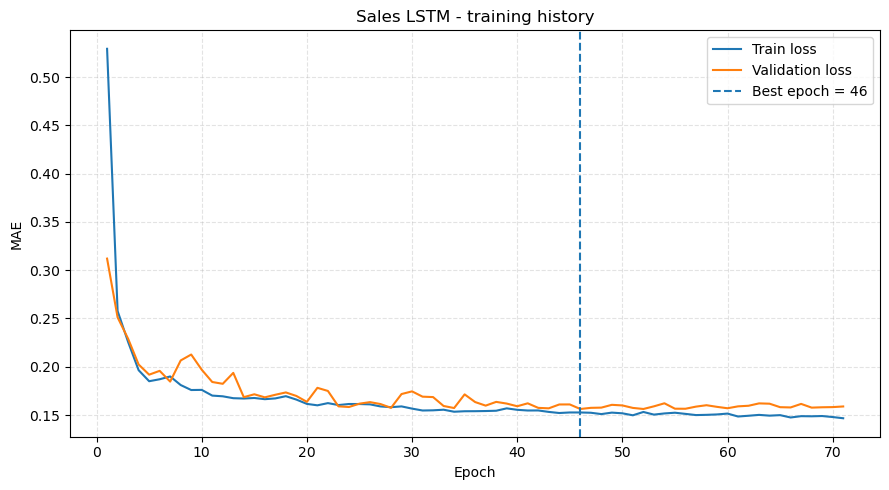

Figura salvata in: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_tuning\figures\sales_lstm_selected_history.png


In [12]:
if not (FINAL_MODEL_DIR / "history.pkl").exists() or not (FINAL_MODEL_DIR / "training_config.pkl").exists():
    print("History o configurazione del modello finale non disponibili.")
else:

    with open(FINAL_MODEL_DIR / "history.pkl", "rb") as f:
        selected_history = pickle.load(f)

    with open(FINAL_MODEL_DIR / "training_config.pkl", "rb") as f:
        selected_config = pickle.load(f)

    history_df = pd.DataFrame(selected_history)
    history_df["epoch"] = range(1, len(history_df) + 1)

    best_epoch = int(selected_config["best_epoch"])

    plt.figure(figsize=(9, 5))
    plt.plot(history_df["epoch"], history_df["loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    plt.axvline(
        best_epoch,
        linestyle="--",
        linewidth=1.5,
        label=f"Best epoch = {best_epoch}",
    )

    plt.xlabel("Epoch")
    plt.ylabel("MAE")
    plt.title("Sales LSTM - training history")
    plt.grid(True, linestyle="--", alpha=0.35)
    plt.legend()
    plt.tight_layout()

    fig_path = FIGURES_DIR / "sales_lstm_selected_history.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Figura salvata in:", fig_path)

## MAE sugli split

Le metriche su train, validation e test sono calcolate sul modello promosso e salvate separatamente. La ricostruzione dei tre split usa scaler, mapping e feature associati a quel modello.

In [13]:
if FINAL_SPLIT_METRICS_PATH.exists() and not FORCE_RECOMPUTE_FINAL_METRICS:
    split_metrics = pd.read_csv(FINAL_SPLIT_METRICS_PATH)
    display(split_metrics)
    print("Metriche già disponibili:", FINAL_SPLIT_METRICS_PATH)
else:

    model = tf.keras.models.load_model(FINAL_MODEL_DIR / "lstm_sales.keras")

    with open(FINAL_MODEL_DIR / "feature_scalers.pkl", "rb") as f:
        feature_scalers = pickle.load(f)

    with open(FINAL_MODEL_DIR / "mappings.pkl", "rb") as f:
        mappings = pickle.load(f)

    with open(FINAL_MODEL_DIR / "features.pkl", "rb") as f:
        features = pickle.load(f)

    with open(FINAL_MODEL_DIR / "training_config.pkl", "rb") as f:
        training_config = pickle.load(f)

    window_size = int(training_config["window_size"])

    train_final, val_final, test_final = build_dataset_train_val_test_from_artifacts(
        df=df,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=window_size,
        train_size=TRAIN_SIZE,
        val_size=VAL_SIZE,
    )

    train_inputs_final = build_model_inputs(train_final)
    val_inputs_final = build_model_inputs(val_final)
    test_inputs_final = build_model_inputs(test_final)

    train_loss, train_mae = model.evaluate(
        train_inputs_final,
        train_final["y"],
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    val_loss, val_mae = model.evaluate(
        val_inputs_final,
        val_final["y"],
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    test_loss, test_mae = model.evaluate(
        test_inputs_final,
        test_final["y"],
        batch_size=BATCH_SIZE,
        verbose=0,
    )

    split_metrics = pd.DataFrame([
        {
            "split": "train",
            "loss": train_loss,
            "mae": train_mae,
            "n_samples": len(train_final["y"]),
        },
        {
            "split": "validation",
            "loss": val_loss,
            "mae": val_mae,
            "n_samples": len(val_final["y"]),
        },
        {
            "split": "test",
            "loss": test_loss,
            "mae": test_mae,
            "n_samples": len(test_final["y"]),
        },
    ])

    metrics_path = FINAL_SPLIT_METRICS_PATH
    split_metrics.to_csv(metrics_path, index=False)

    display(split_metrics)
    print("Metriche salvate in:", metrics_path)

,split,loss,mae,n_samples
0,train,0.157199,0.157199,17610
1,validation,0.156236,0.156236,2280
2,test,0.168649,0.168649,4840


Metriche già disponibili: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\lstm_tuning\final_model_split_metrics.csv


## Nota metodologica

La scelta della configurazione usa esclusivamente `best_val_loss`, cioè la MAE sul validation set nella scala trasformata e standardizzata impiegata nel training.

Il modello finale e gli artifact associati vengono poi caricati dalle pipeline di valutazione delle anomalie.